In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("/content/Grammar Correction.csv")

In [ ]:
df.head()

,Serial Number,Error Type,Ungrammatical Statement,Standard English
0,1,Verb Tense Errors,I goes to the store everyday.,I go to the store everyday.
1,2,Verb Tense Errors,They was playing soccer last night.,They were playing soccer last night.
2,3,Verb Tense Errors,She have completed her homework.,She has completed her homework.
3,4,Verb Tense Errors,He don't know the answer.,He doesn't know the answer.
4,5,Verb Tense Errors,The sun rise in the east.,The sun rises in the east.


In [ ]:
df.shape

(2018, 4)

In [ ]:
df

,Serial Number,Error Type,Ungrammatical Statement,Standard English
0,1,Verb Tense Errors,I goes to the store everyday.,I go to the store everyday.
1,2,Verb Tense Errors,They was playing soccer last night.,They were playing soccer last night.
2,3,Verb Tense Errors,She have completed her homework.,She has completed her homework.
3,4,Verb Tense Errors,He don't know the answer.,He doesn't know the answer.
4,5,Verb Tense Errors,The sun rise in the east.,The sun rises in the east.
...,...,...,...,...
2013,2014,Lack of Parallelism in Lists or Series,"The festival celebrates music, culture, and to...","The festival celebrates music, culture, and br..."
2014,2015,Lack of Parallelism in Lists or Series,The seminar will address topics such as career...,The seminar will address topics such as career...
2015,2016,Lack of Parallelism in Lists or Series,The research examines the effects of climate c...,The research examines the effects of climate c...
2016,2017,Lack of Parallelism in Lists or Series,"The report highlights the need for investment,...","The report highlights the need for investment,..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2018 entries, 0 to 2017
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Serial Number            2018 non-null   int64 
 1   Error Type               2018 non-null   object
 2   Ungrammatical Statement  2018 non-null   object
 3   Standard English         2018 non-null   object
dtypes: int64(1), object(3)
memory usage: 63.2+ KB


In [ ]:
df.isna().sum()

,0
Serial Number,0
Error Type,0
Ungrammatical Statement,0
Standard English,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Error Type'].value_counts()

,count
Error Type,
Sentence Structure Errors,103
Verb Tense Errors,100
Article Usage,100
Subject-Verb Agreement,100
Spelling Mistakes,100
Preposition Usage,95
Punctuation Errors,60
Relative Clause Errors,51
Ambiguity,50


In [ ]:
import pandas as pd
pd.set_option('display.max_colwidth', None)

for et in ['Spelling Mistakes', 'Sentence Structure Errors', 'Ellipsis Errors', 'Redundancy/Repetition']:
    print(f"\n=== {et} ===")
    sample = df[df['Error Type'] == et][['Ungrammatical Statement', 'Standard English']].head(3)
    for _, row in sample.iterrows():
        print("IN: ", row['Ungrammatical Statement'])
        print("OUT:", row['Standard English'])
        print()


=== Spelling Mistakes ===
IN:  1. She always be triying new things.
OUT: 1. She always tries new things.

IN:  2. John and me went to the store yesterday.
OUT: 2. John and I went to the store yesterday.

IN:  3. The books is on the shelf in the library.
OUT: 3. The book is on the shelf in the library.


=== Sentence Structure Errors ===
IN:  I be going to the store to buy groceries.
OUT: I am going to the store to buy groceries.

IN:  He no likes pineapple on his pizza.
OUT: He doesn't like pineapple on his pizza.

IN:  She very tired after the long day at work.
OUT: She is very tired after the long day at work.


=== Ellipsis Errors ===
IN:  I went to the store... bought milk.
OUT: I went to the store and bought milk.

IN:  She was so tired... couldn't keep her eyes open.
OUT: She was so tired that she couldn't keep her eyes open.

IN:  Can't believe... leaving so soon.
OUT: I can't believe you're leaving so soon.


=== Redundancy/Repetition ===
IN:  I went to the store store.
OUT: I

In [ ]:
df['src_len'] = df['Ungrammatical Statement'].apply(lambda x: len(x.split()))
df['tgt_len'] = df['Standard English'].apply(lambda x: len(x.split()))

print(df[['src_len', 'tgt_len']].describe())
print("\nMax src length:", df['src_len'].max())
print("Longest sentence:", df.loc[df['src_len'].idxmax(), 'Ungrammatical Statement'])

           src_len      tgt_len
count  2018.000000  2018.000000
mean      8.989098     8.725471
std       2.520886     2.273111
min       3.000000     2.000000
25%       7.000000     7.000000
50%       9.000000     9.000000
75%      10.000000    10.000000
max      22.000000    18.000000

Max src length: 22
Longest sentence: 7. I'll cross that bridge when I come to it, but a bird in the hand is worth two in the bush.


In [ ]:
from collections import Counter

def simple_tokenize(text):
    return text.strip().lower().split()

all_tokens = []
for _, row in df.iterrows():
    all_tokens.extend(simple_tokenize(row['Ungrammatical Statement']))
    all_tokens.extend(simple_tokenize(row['Standard English']))

vocab_counter = Counter(all_tokens)
print("Total unique tokens (before adding special tokens):", len(vocab_counter))
print("\nTop 20 most common tokens:")
print(vocab_counter.most_common(20))
print("\nTokens appearing only once:", sum(1 for v in vocab_counter.values() if v == 1))

Total unique tokens (before adding special tokens): 4970

Top 20 most common tokens:
[('the', 4195), ('to', 1011), ('is', 918), ('a', 883), ('was', 673), ('and', 645), ('in', 530), ('of', 507), ('i', 486), ('she', 467), ('he', 361), ('for', 304), ('on', 279), ('at', 247), ('are', 222), ('by', 221), ('new', 185), ('this', 180), ('but', 174), ('have', 165)]

Tokens appearing only once: 1247


In [ ]:
PAD, UNK, START, END = '<PAD>', '<UNK>', '<START>', '<END>'

MIN_FREQ = 2  # words seen only once get folded into <UNK>

vocab_words = [w for w, c in vocab_counter.items() if c >= MIN_FREQ]
vocab_words = sorted(vocab_words)

itos = [PAD, UNK, START, END] + vocab_words
stoi = {word: idx for idx, word in enumerate(itos)}

print("Final vocab size:", len(itos))
print("Words dropped to <UNK> (freq==1):", len(vocab_counter) - len(vocab_words))
print("\nFirst 10 vocab entries:", itos[:10])
print("Sample stoi lookups:", {w: stoi[w] for w in ['the', 'she', 'was', UNK]})

Final vocab size: 3727
Words dropped to <UNK> (freq==1): 1247

First 10 vocab entries: ['<PAD>', '<UNK>', '<START>', '<END>', '"can', '"you', '(nasa)', '1', '1.', '10']
Sample stoi lookups: {'the': 3294, 'she': 2910, 'was': 3572, '<UNK>': 1}


In [ ]:
import re

def tokenize(text):
    text = text.strip().lower()
    # separate punctuation (.,!?;:'"()) from words, keep contractions like "don't" intact
    tokens = re.findall(r"[a-z]+(?:'[a-z]+)?|[.,!?;:()\"]", text)
    return tokens

# rebuild vocab with the fixed tokenizer
all_tokens = []
for _, row in df.iterrows():
    all_tokens.extend(tokenize(row['Ungrammatical Statement']))
    all_tokens.extend(tokenize(row['Standard English']))

vocab_counter = Counter(all_tokens)
print("Total unique tokens (fixed tokenizer):", len(vocab_counter))
print("Tokens appearing only once:", sum(1 for v in vocab_counter.values() if v == 1))
print("\nTop 15 tokens:", vocab_counter.most_common(15))

# sanity check: tokenize one example
sample = df.iloc[0]['Ungrammatical Statement']
print("\nSample:", sample)
print("Tokenized:", tokenize(sample))

Total unique tokens (fixed tokenizer): 3557
Tokens appearing only once: 637

Top 15 tokens: [('.', 4500), ('the', 4197), (',', 1161), ('to', 1013), ('is', 922), ('a', 883), ('was', 673), ('and', 647), ('in', 535), ('of', 508), ('i', 497), ('she', 467), ('he', 363), ('for', 306), ('on', 284)]

Sample: I goes to the store everyday.
Tokenized: ['i', 'goes', 'to', 'the', 'store', 'everyday', '.']


In [ ]:
PAD, UNK, START, END = '<PAD>', '<UNK>', '<START>', '<END>'
MIN_FREQ = 2

vocab_words = sorted([w for w, c in vocab_counter.items() if c >= MIN_FREQ])
itos = [PAD, UNK, START, END] + vocab_words
stoi = {word: idx for idx, word in enumerate(itos)}

print("Final vocab size:", len(itos))

# encode all source and target sentences
src_sequences = [tokenize(t) for t in df['Ungrammatical Statement']]
tgt_sequences = [[START] + tokenize(t) + [END] for t in df['Standard English']]

src_lens = [len(s) for s in src_sequences]
tgt_lens = [len(t) for t in tgt_sequences]

print("Max src len:", max(src_lens), " Max tgt len (with START/END):", max(tgt_lens))

# sanity check on one example
print("\nSrc tokens:", src_sequences[0])
print("Tgt tokens:", tgt_sequences[0])

def encode(tokens, stoi):
    return [stoi.get(t, stoi[UNK]) for t in tokens]

print("\nSrc encoded:", encode(src_sequences[0], stoi))
print("Tgt encoded:", encode(tgt_sequences[0], stoi))

Final vocab size: 2924
Max src len: 24  Max tgt len (with START/END): 22

Src tokens: ['i', 'goes', 'to', 'the', 'store', 'everyday', '.']
Tgt tokens: ['<START>', 'i', 'go', 'to', 'the', 'store', 'everyday', '.', '<END>']

Src encoded: [1312, 1153, 2633, 2587, 2443, 928, 9]
Tgt encoded: [2, 1312, 1150, 2633, 2587, 2443, 928, 9, 3]


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
import numpy as np

MAX_SRC_LEN = 25   # a little headroom above 24
MAX_TGT_LEN = 24   # a little headroom above 22

src_encoded = [encode(s, stoi) for s in src_sequences]
tgt_encoded = [encode(t, stoi) for t in tgt_sequences]

X = pad_sequences(src_encoded, maxlen=MAX_SRC_LEN, padding='post', value=stoi[PAD])
Y = pad_sequences(tgt_encoded, maxlen=MAX_TGT_LEN, padding='post', value=stoi[PAD])

print("X shape:", X.shape, " Y shape:", Y.shape)

# stratified split by Error Type
error_types = df['Error Type'].values
idx = np.arange(len(df))

train_idx, temp_idx = train_test_split(idx, test_size=0.2, random_state=42, stratify=error_types)
dev_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42, stratify=error_types[temp_idx])

X_train, Y_train = X[train_idx], Y[train_idx]
X_dev, Y_dev = X[dev_idx], Y[dev_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

print("Train:", X_train.shape, " Dev:", X_dev.shape, " Test:", X_test.shape)
print("\nSample padded src:", X_train[0])
print("Sample padded tgt:", Y_train[0])

X shape: (2018, 25)  Y shape: (2018, 24)
Train: (1614, 25)  Dev: (202, 25)  Test: (202, 25)

Sample padded src: [2587 2377 2803 1874  366 2587  476  180 2587  581    9    0    0    0
    0    0    0    0    0    0    0    0    0    0    0]
Sample padded tgt: [   2 2587  476 1874 2587 2377  180 2587  581    9    3    0    0    0
    0    0    0    0    0    0    0    0    0    0]


In [ ]:
# Build binary classification data: incorrect sentences (label=0) + correct sentences (label=1)
cls_texts = list(df['Ungrammatical Statement']) + list(df['Standard English'])
cls_labels = [0] * len(df) + [1] * len(df)

print("Total examples:", len(cls_texts))
print("Label distribution:", np.bincount(cls_labels))

# tokenize + encode (reuse our tokenizer/stoi, no START/END needed for classification)
cls_encoded = [encode(tokenize(t), stoi) for t in cls_texts]
cls_lens = [len(s) for s in cls_encoded]
print("Max len:", max(cls_lens))

MAX_CLS_LEN = 25
X_cls = pad_sequences(cls_encoded, maxlen=MAX_CLS_LEN, padding='post', value=stoi[PAD])
y_cls = np.array(cls_labels)

# stratified split (by label this time, simple 80/10/10)
idx_cls = np.arange(len(X_cls))
train_idx_c, temp_idx_c = train_test_split(idx_cls, test_size=0.2, random_state=42, stratify=y_cls)
dev_idx_c, test_idx_c = train_test_split(temp_idx_c, test_size=0.5, random_state=42, stratify=y_cls[temp_idx_c])

X_train_c, y_train_c = X_cls[train_idx_c], y_cls[train_idx_c]
X_dev_c, y_dev_c = X_cls[dev_idx_c], y_cls[dev_idx_c]
X_test_c, y_test_c = X_cls[test_idx_c], y_cls[test_idx_c]

print("Train:", X_train_c.shape, "Dev:", X_dev_c.shape, "Test:", X_test_c.shape)

Total examples: 4036
Label distribution: [2018 2018]
Max len: 24
Train: (3228, 25) Dev: (404, 25) Test: (404, 25)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

VOCAB_SIZE = len(itos)
EMBED_DIM = 64

model = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_CLS_LEN, mask_zero=True),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = models.Sequential([
    layers.Input(shape=(MAX_CLS_LEN,)),
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, mask_zero=True),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 25, 64)         │       187,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,249 (739.25 KB)

 Trainable params: 189,249 (739.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_c, y_train_c,
    validation_data=(X_dev_c, y_dev_c),
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.4913 - loss: 0.6935 - val_accuracy: 0.5124 - val_loss: 0.6928
Epoch 2/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5809 - loss: 0.6887 - val_accuracy: 0.5025 - val_loss: 0.6930
Epoch 3/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6007 - loss: 0.6733 - val_accuracy: 0.4703 - val_loss: 0.7093
Epoch 4/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6481 - loss: 0.6403 - val_accuracy: 0.4307 - val_loss: 0.7666
Epoch 5/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6713 - loss: 0.6092 - val_accuracy: 0.4208 - val_loss: 0.8327
Epoch 6/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7014 - loss: 0.5742 - val_accuracy: 0.4035 - val_loss: 0.9047
Epoch 7/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7193 - loss: 0.5483 - val_accuracy: 0.4134 - val_loss: 0.9915
Epoch 8/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7311 - loss: 0.5203 - val_accuracy: 0

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix on test set
y_pred_probs = model.predict(X_test_c)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print("Confusion Matrix:")
print(confusion_matrix(y_test_c, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred, target_names=['Incorrect (0)', 'Correct (1)']))

# Manual test on new sentences
def predict_sentence(text):
    tokens = encode(tokenize(text), stoi)
    padded = pad_sequences([tokens], maxlen=MAX_CLS_LEN, padding='post', value=stoi[PAD])
    prob = model.predict(padded, verbose=0)[0][0]
    label = "Correct" if prob > 0.5 else "Incorrect"
    return prob, label

test_sentences = [
    "John and me went to the store yesterday.",   # incorrect (swapped order test)
    "John and I went to the store yesterday.",     # correct
    "Me and John went to the store yesterday.",    # incorrect, different word order
    "She go to school every day.",                 # incorrect
    "She goes to school every day.",               # correct
]

print("\nManual predictions:")
for s in test_sentences:
    prob, label = predict_sentence(s)
    print(f"{label:10s} (p={prob:.3f})  |  {s}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step
Confusion Matrix:
[[ 81 121]
 [143  59]]

Classification Report:
               precision    recall  f1-score   support

Incorrect (0)       0.36      0.40      0.38       202
  Correct (1)       0.33      0.29      0.31       202

     accuracy                           0.35       404
    macro avg       0.34      0.35      0.34       404
 weighted avg       0.34      0.35      0.34       404


Manual predictions:
Incorrect  (p=0.310)  |  John and me went to the store yesterday.
Correct    (p=0.885)  |  John and I went to the store yesterday.
Incorrect  (p=0.310)  |  Me and John went to the store yesterday.
Correct    (p=0.781)  |  She go to school every day.
Incorrect  (p=0.252)  |  She goes to school every day.


In [ ]:
# Save the full model (architecture + weights + optimizer state)
model.save('/content/phase1_embedding_model.keras')

print("Model saved to /content/phase1_embedding_model.keras")

Model saved to /content/phase1_embedding_model.keras


In [ ]:
print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_dev:", X_dev.shape, "Y_dev:", Y_dev.shape)
print("X_test:", X_test.shape, "Y_test:", Y_test.shape)

print("\nSample X (source, padded to 25):", X_train[0])
print("Sample Y (target, padded to 24, starts with <START>=2):", Y_train[0])

X_train: (1614, 25) Y_train: (1614, 24)
X_dev: (202, 25) Y_dev: (202, 24)
X_test: (202, 25) Y_test: (202, 24)

Sample X (source, padded to 25): [2587 2377 2803 1874  366 2587  476  180 2587  581    9    0    0    0
    0    0    0    0    0    0    0    0    0    0    0]
Sample Y (target, padded to 24, starts with <START>=2): [   2 2587  476 1874 2587 2377  180 2587  581    9    3    0    0    0
    0    0    0    0    0    0    0    0    0    0]


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

VOCAB_SIZE = len(itos)
EMBED_DIM = 64
HIDDEN_DIM = 128

# --- Encoder ---
encoder_inputs = layers.Input(shape=(MAX_SRC_LEN,), name="encoder_input")
encoder_embedding = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="encoder_embedding")(encoder_inputs)
encoder_rnn = layers.SimpleRNN(HIDDEN_DIM, return_state=True, name="encoder_rnn")
encoder_outputs, encoder_state = encoder_rnn(encoder_embedding)

# quick standalone check: what shape is the encoder's final hidden state?
encoder_model_debug = models.Model(encoder_inputs, encoder_state)
sample_output = encoder_model_debug.predict(X_train[:2])
print("Encoder hidden state shape:", sample_output.shape)
print("Sample encoder state (first 10 values of example 0):", sample_output[0][:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
Encoder hidden state shape: (2, 128)
Sample encoder state (first 10 values of example 0): [-0.05910854 -0.08805923  0.14319271  0.0299574  -0.07498275 -0.07096697
  0.00318481 -0.01291826  0.09201661 -0.06846879]


In [ ]:
# --- Decoder ---
decoder_inputs = layers.Input(shape=(MAX_TGT_LEN,), name="decoder_input")
decoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="decoder_embedding")
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_rnn = layers.SimpleRNN(HIDDEN_DIM, return_sequences=True, return_state=True, name="decoder_rnn")
decoder_outputs, _ = decoder_rnn(decoder_embedding, initial_state=encoder_state)

decoder_dense = layers.Dense(VOCAB_SIZE, activation='softmax', name="decoder_output")
decoder_predictions = decoder_dense(decoder_outputs)

# --- Full seq2seq model ---
rnn_model = models.Model([encoder_inputs, decoder_inputs], decoder_predictions)
rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 25, 64)    │    187,136 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 25)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 24, 64)    │    187,136 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_rnn         │ [(None, 128),     │     24,704 │ encoder_embeddin… │
│ (SimpleRNN)         │ (None, 128)]      │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_rnn         │ [(None, 24, 128), │     24,704 │ decoder_embeddin… │
│ (SimpleRNN)         │ (None, 128)]      │            │ encoder_rnn[0][1] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 24, 2924)  │    377,196 │ decoder_rnn[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 800,876 (3.06 MB)

 Trainable params: 800,876 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Decoder input: everything except the last token (so it starts with <START>)
decoder_input_train = Y_train[:, :-1]
decoder_input_dev = Y_dev[:, :-1]

# Decoder target: everything except the first token (so it starts predicting the word after <START>)
decoder_target_train = Y_train[:, 1:]
decoder_target_dev = Y_dev[:, 1:]

print("Decoder input shape:", decoder_input_train.shape)
print("Decoder target shape:", decoder_target_train.shape)

print("\nSample decoder input: ", decoder_input_train[0])
print("Sample decoder target:", decoder_target_train[0])

Decoder input shape: (1614, 23)
Decoder target shape: (1614, 23)

Sample decoder input:  [   2 2587  476 1874 2587 2377  180 2587  581    9    3    0    0    0
    0    0    0    0    0    0    0    0    0]
Sample decoder target: [2587  476 1874 2587 2377  180 2587  581    9    3    0    0    0    0
    0    0    0    0    0    0    0    0    0]


In [ ]:
DECODER_LEN = MAX_TGT_LEN - 1  # 23

# --- Encoder (unchanged) ---
encoder_inputs = layers.Input(shape=(MAX_SRC_LEN,), name="encoder_input")
encoder_embedding = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="encoder_embedding")(encoder_inputs)
encoder_rnn = layers.SimpleRNN(HIDDEN_DIM, return_state=True, name="encoder_rnn")
encoder_outputs, encoder_state = encoder_rnn(encoder_embedding)

# --- Decoder (fixed length) ---
decoder_inputs = layers.Input(shape=(DECODER_LEN,), name="decoder_input")
decoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="decoder_embedding")
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_rnn = layers.SimpleRNN(HIDDEN_DIM, return_sequences=True, return_state=True, name="decoder_rnn")
decoder_outputs, _ = decoder_rnn(decoder_embedding, initial_state=encoder_state)

decoder_dense = layers.Dense(VOCAB_SIZE, activation='softmax', name="decoder_output")
decoder_predictions = decoder_dense(decoder_outputs)

rnn_model = models.Model([encoder_inputs, decoder_inputs], decoder_predictions)
rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 25, 64)    │    187,136 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 25)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 23, 64)    │    187,136 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_rnn         │ [(None, 128),     │     24,704 │ encoder_embeddin… │
│ (SimpleRNN)         │ (None, 128)]      │            │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_rnn         │ [(None, 23, 128), │     24,704 │ decoder_embeddin… │
│ (SimpleRNN)         │ (None, 128)]      │            │ encoder_rnn[0][1] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 23, 2924)  │    377,196 │ decoder_rnn[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 800,876 (3.06 MB)

 Trainable params: 800,876 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
decoder_target_dev = Y_dev[:, 1:]  # already have decoder_input_dev from before

history_rnn = rnn_model.fit(
    [X_train, decoder_input_train], decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - accuracy: 0.1254 - loss: 6.2818 - val_accuracy: 0.2086 - val_loss: 5.5157
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2491 - loss: 5.2413 - val_accuracy: 0.2910 - val_loss: 5.1521
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2932 - loss: 4.8143 - val_accuracy: 0.3137 - val_loss: 4.7970
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3209 - loss: 4.5249 - val_accuracy: 0.3307 - val_loss: 4.6012
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3350 - loss: 4.2941 - val_accuracy: 0.3390 - val_loss: 4.4727
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3539 - loss: 4.1018 - val_accuracy: 0.3539 - val_loss: 4.3869
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3671 - loss: 3.9417 - val_accuracy: 0.3547 - val_loss: 4.3403
Epoch 8/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3779 - loss: 3.7892 - val_accuracy: 0.3692 - val_los

In [ ]:
import numpy as np

pad_id = stoi['<PAD>']
non_pad_fraction = np.mean(decoder_target_train != pad_id)
print(f"Fraction of decoder_target_train that is NOT padding: {non_pad_fraction:.3f}")
print(f"Fraction that IS padding: {1 - non_pad_fraction:.3f}")

Fraction of decoder_target_train that is NOT padding: 0.481
Fraction that IS padding: 0.519


In [ ]:
import tensorflow as tf

def masked_loss(y_true, y_pred):
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)  # 0 = <PAD> id
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(reduction='none')
    loss = loss_fn(y_true, y_pred)
    loss *= mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    y_pred_labels = tf.argmax(y_pred, axis=-1)
    y_true = tf.cast(y_true, y_pred_labels.dtype)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    correct = tf.cast(tf.equal(y_true, y_pred_labels), tf.float32) * mask
    return tf.reduce_sum(correct) / tf.reduce_sum(mask)

# recompile the SAME model with masked metrics (weights are preserved, just changing loss/metric tracking going forward)
rnn_model.compile(optimizer='adam', loss=masked_loss, metrics=[masked_accuracy])

# continue training with the honest metric
history_rnn_masked = rnn_model.fit(
    [X_train, decoder_input_train], decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30


ValueError: Shape must be at most rank 0 but is rank 2 for '{{node BroadcastTo_1}} = BroadcastTo[T=DT_FLOAT, Tidx=DT_INT32](Cast_5, BroadcastTo_1/shape_1)' with input shapes: [?,23], [0].

In [ ]:
import tensorflow as tf

def masked_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    # squeeze a trailing dim of size 1 if present, e.g. (batch, seq, 1) -> (batch, seq)
    if len(y_true.shape) == len(y_pred.shape):
        y_true = tf.squeeze(y_true, axis=-1)

    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)  # 0 = <PAD> id
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(reduction='none')
    loss = loss_fn(y_true, y_pred)  # shape: (batch, seq)
    loss = loss * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    if len(y_true.shape) == len(y_pred.shape):
        y_true = tf.squeeze(y_true, axis=-1)

    y_pred_labels = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    correct = tf.cast(tf.equal(y_true, y_pred_labels), tf.float32) * mask
    return tf.reduce_sum(correct) / tf.reduce_sum(mask)

rnn_model.compile(optimizer='adam', loss=masked_loss, metrics=[masked_accuracy])

history_rnn_masked = rnn_model.fit(
    [X_train, decoder_input_train], decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30


ValueError: Shape must be at most rank 0 but is rank 2 for '{{node BroadcastTo_1}} = BroadcastTo[T=DT_FLOAT, Tidx=DT_INT32](Cast_5, BroadcastTo_1/shape_1)' with input shapes: [?,23], [0].

In [ ]:
DECODER_LEN = MAX_TGT_LEN - 1  # 23

# --- Encoder (mask_zero removed) ---
encoder_inputs = layers.Input(shape=(MAX_SRC_LEN,), name="encoder_input")
encoder_embedding = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="encoder_embedding")(encoder_inputs)
encoder_rnn = layers.SimpleRNN(HIDDEN_DIM, return_state=True, name="encoder_rnn")
encoder_outputs, encoder_state = encoder_rnn(encoder_embedding)

# --- Decoder (mask_zero removed) ---
decoder_inputs = layers.Input(shape=(DECODER_LEN,), name="decoder_input")
decoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="decoder_embedding")
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_rnn = layers.SimpleRNN(HIDDEN_DIM, return_sequences=True, return_state=True, name="decoder_rnn")
decoder_outputs, _ = decoder_rnn(decoder_embedding, initial_state=encoder_state)

decoder_dense = layers.Dense(VOCAB_SIZE, activation='softmax', name="decoder_output")
decoder_predictions = decoder_dense(decoder_outputs)

rnn_model = models.Model([encoder_inputs, decoder_inputs], decoder_predictions)
rnn_model.compile(optimizer='adam', loss=masked_loss, metrics=[masked_accuracy])
rnn_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 25, 64)    │    187,136 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 23, 64)    │    187,136 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_rnn         │ [(None, 128),     │     24,704 │ encoder_embeddin… │
│ (SimpleRNN)         │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_rnn         │ [(None, 23, 128), │     24,704 │ decoder_embeddin… │
│ (SimpleRNN)         │ (None, 128)]      │            │ encoder_rnn[0][1] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 23, 2924)  │    377,196 │ decoder_rnn[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 800,876 (3.06 MB)

 Trainable params: 800,876 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_rnn_masked = rnn_model.fit(
    [X_train, decoder_input_train], decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 6.4591 - masked_accuracy: 0.1440 - val_loss: 5.4924 - val_masked_accuracy: 0.1676
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 5.2269 - masked_accuracy: 0.2340 - val_loss: 5.2587 - val_masked_accuracy: 0.2592
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.9444 - masked_accuracy: 0.2595 - val_loss: 5.0707 - val_masked_accuracy: 0.2625
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.7179 - masked_accuracy: 0.2691 - val_loss: 4.9274 - val_masked_accuracy: 0.2689
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.5169 - masked_accuracy: 0.2835 - val_loss: 4.8165 - val_masked_accuracy: 0.2841
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.3368 - masked_accuracy: 0.3003 - val_loss: 4.7550 - val_masked_accuracy: 0.2908
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.1816 - masked_accuracy: 0.3123 - val_loss: 4.7013 - val_masked_accuracy: 0.3036
Epoch 8/30
51/51 

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# rebuild fresh so we start from scratch, not from the already-overfit epoch-30 weights
encoder_inputs = layers.Input(shape=(MAX_SRC_LEN,), name="encoder_input")
encoder_embedding = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="encoder_embedding")(encoder_inputs)
encoder_rnn = layers.SimpleRNN(HIDDEN_DIM, return_state=True, name="encoder_rnn")
encoder_outputs, encoder_state = encoder_rnn(encoder_embedding)

decoder_inputs = layers.Input(shape=(DECODER_LEN,), name="decoder_input")
decoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="decoder_embedding")
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_rnn = layers.SimpleRNN(HIDDEN_DIM, return_sequences=True, return_state=True, name="decoder_rnn")
decoder_outputs, _ = decoder_rnn(decoder_embedding, initial_state=encoder_state)

decoder_dense = layers.Dense(VOCAB_SIZE, activation='softmax', name="decoder_output")
decoder_predictions = decoder_dense(decoder_outputs)

rnn_model = models.Model([encoder_inputs, decoder_inputs], decoder_predictions)
rnn_model.compile(optimizer='adam', loss=masked_loss, metrics=[masked_accuracy])

early_stop = EarlyStopping(
    monitor='val_masked_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_rnn_final = rnn_model.fit(
    [X_train, decoder_input_train], decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("\nBest val_masked_accuracy:", max(history_rnn_final.history['val_masked_accuracy']))

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - loss: 6.4267 - masked_accuracy: 0.1720 - val_loss: 5.6946 - val_masked_accuracy: 0.2270
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.4775 - masked_accuracy: 0.2219 - val_loss: 5.5062 - val_masked_accuracy: 0.2257
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.1903 - masked_accuracy: 0.2290 - val_loss: 5.1840 - val_masked_accuracy: 0.2497
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.9163 - masked_accuracy: 0.2569 - val_loss: 4.9818 - val_masked_accuracy: 0.2677
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.6752 - masked_accuracy: 0.2787 - val_loss: 4.8571 - val_masked_accuracy: 0.2828
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.4563 - masked_accuracy: 0.2947 - val_loss: 4.7468 - val_masked_accuracy: 0.2983
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.2753 - masked_accuracy: 0.3085 - val_loss: 4.6970 - val_masked_accuracy: 0.3051
Epoch 8/30
51

In [ ]:
def correct_sentence(input_text, max_len=DECODER_LEN):
    # encode source
    src_tokens = encode(tokenize(input_text), stoi)
    src_padded = pad_sequences([src_tokens], maxlen=MAX_SRC_LEN, padding='post', value=stoi[PAD])

    # get encoder state
    encoder_infer_model = models.Model(encoder_inputs, encoder_state)
    state = encoder_infer_model.predict(src_padded, verbose=0)

    # decode step by step, starting from <START>
    decoder_infer_input = np.zeros((1, max_len))
    decoder_infer_input[0, 0] = stoi[START]

    output_tokens = []
    current_state = state

    for t in range(max_len - 1):
        # run one decoder step manually using the decoder layer directly
        current_input = decoder_infer_input[:, :t+1]
        padded_input = np.zeros((1, max_len))
        padded_input[0, :t+1] = current_input[0, :t+1]

        preds = rnn_model.predict([src_padded, padded_input], verbose=0)
        next_token_id = np.argmax(preds[0, t])

        if itos[next_token_id] == END:
            break
        output_tokens.append(itos[next_token_id])
        if t + 1 < max_len:
            decoder_infer_input[0, t+1] = next_token_id

    return ' '.join(output_tokens)

test_sentences = [
    "She go to school every day.",
    "John and me went to the store yesterday.",
    "He no likes pineapple on his pizza.",
    "The books is on the shelf.",
]

for s in test_sentences:
    corrected = correct_sentence(s)
    print(f"IN:  {s}")
    print(f"OUT: {corrected}")
    print()

IN:  She go to school every day.
OUT: the cake was delicious , and the project .

IN:  John and me went to the store yesterday.
OUT: the cake was delicious , and the project .

IN:  He no likes pineapple on his pizza.
OUT: the cake was delicious , and the project .

IN:  The books is on the shelf.
OUT: the cake was delicious , and the project .



In [ ]:
target_sentences = df['Standard English'].str.lower().tolist()
matches = [t for t in target_sentences if "cake" in t.lower() and "delicious" in t.lower()]
print("Training examples containing 'cake' and 'delicious':")
for m in matches:
    print(" -", m)

encoder_infer_model = models.Model(encoder_inputs, encoder_state)

s1 = pad_sequences([encode(tokenize("She go to school every day."), stoi)], maxlen=MAX_SRC_LEN, padding='post', value=stoi[PAD])
s2 = pad_sequences([encode(tokenize("The books is on the shelf."), stoi)], maxlen=MAX_SRC_LEN, padding='post', value=stoi[PAD])

state1 = encoder_infer_model.predict(s1, verbose=0)
state2 = encoder_infer_model.predict(s2, verbose=0)

print("\nAre encoder states identical across different inputs?", np.allclose(state1, state2))
print("Max abs difference:", np.max(np.abs(state1 - state2)))

Training examples containing 'cake' and 'delicious':
 - the cake was delicious, but it was too sweet.
 - the cake was delicious; however, it was too sweet for my taste.
 - the cake is delicious, and everyone enjoyed it.
 - the cake was delicious, with everyone wanting more.
 - the cake is delicious and not too sweet.
 - the cake is more delicious than the pie, but less delicious than the ice cream.
 - the cake was delicious, but i ate too much.
 - the cake i ate for dessert was delicious.
 - the cake was delicious, moist, and beautifully decorated.

Are encoder states identical across different inputs? True
Max abs difference: 2.3841858e-07


In [ ]:
encoder_inputs = layers.Input(shape=(MAX_SRC_LEN,), name="encoder_input")
encoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="encoder_embedding")
encoder_embedding = encoder_embedding_layer(encoder_inputs)
encoder_masking = layers.Masking(mask_value=0.0)(encoder_embedding)  # explicit masking on embedded vectors won't work directly since embedding of PAD isn't 0.0...

In [ ]:
encoder_inputs = layers.Input(shape=(MAX_SRC_LEN,), name="encoder_input")
encoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="encoder_embedding")
encoder_embedding = encoder_embedding_layer(encoder_inputs)
encoder_rnn = layers.SimpleRNN(HIDDEN_DIM, return_state=True, name="encoder_rnn")
encoder_outputs, encoder_state = encoder_rnn(encoder_embedding)  # mask flows automatically from embedding to RNN

# decoder stays WITHOUT mask_zero (this is what caused the loss-function conflict earlier —
# only the encoder embedding needs masking; decoder side doesn't feed into masked_loss the same way)
decoder_inputs = layers.Input(shape=(DECODER_LEN,), name="decoder_input")
decoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="decoder_embedding")
decoder_embedding = decoder_embedding_layer(decoder_inputs)
decoder_rnn = layers.SimpleRNN(HIDDEN_DIM, return_sequences=True, return_state=True, name="decoder_rnn")
decoder_outputs, _ = decoder_rnn(decoder_embedding, initial_state=encoder_state)

decoder_dense = layers.Dense(VOCAB_SIZE, activation='softmax', name="decoder_output")
decoder_predictions = decoder_dense(decoder_outputs)

rnn_model = models.Model([encoder_inputs, decoder_inputs], decoder_predictions)
rnn_model.compile(optimizer='adam', loss=masked_loss, metrics=[masked_accuracy])

In [ ]:
early_stop = EarlyStopping(
    monitor='val_masked_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_rnn_final = rnn_model.fit(
    [X_train, decoder_input_train], decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("\nBest val_masked_accuracy:", max(history_rnn_final.history['val_masked_accuracy']))

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - loss: 6.4134 - masked_accuracy: 0.1280 - val_loss: 5.7295 - val_masked_accuracy: 0.1354
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.5136 - masked_accuracy: 0.1606 - val_loss: 5.5933 - val_masked_accuracy: 0.1678
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.2891 - masked_accuracy: 0.2223 - val_loss: 5.3154 - val_masked_accuracy: 0.2327
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.9903 - masked_accuracy: 0.2449 - val_loss: 5.1277 - val_masked_accuracy: 0.2594
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.7599 - masked_accuracy: 0.2735 - val_loss: 4.8862 - val_masked_accuracy: 0.2764
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.5141 - masked_accuracy: 0.2932 - val_loss: 4.8005 - val_masked_accuracy: 0.2899
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.3408 - masked_accuracy: 0.3090 - val_loss: 4.7411 - val_masked_accuracy: 0.3013
Epoch 8/30
51/51 

In [ ]:
encoder_infer_model = models.Model(encoder_inputs, encoder_state)

s1 = pad_sequences([encode(tokenize("She go to school every day."), stoi)], maxlen=MAX_SRC_LEN, padding='post', value=stoi[PAD])
s2 = pad_sequences([encode(tokenize("The books is on the shelf."), stoi)], maxlen=MAX_SRC_LEN, padding='post', value=stoi[PAD])

state1 = encoder_infer_model.predict(s1, verbose=0)
state2 = encoder_infer_model.predict(s2, verbose=0)

print("Are encoder states identical now?", np.allclose(state1, state2))
print("Max abs difference:", np.max(np.abs(state1 - state2)))

print()

test_sentences = [
    "She go to school every day.",
    "John and me went to the store yesterday.",
    "He no likes pineapple on his pizza.",
    "The books is on the shelf.",
]

for s in test_sentences:
    corrected = correct_sentence(s)
    print(f"IN:  {s}")
    print(f"OUT: {corrected}")
    print()

Are encoder states identical now? False
Max abs difference: 1.9804206



IN:  She go to school every day.
OUT: she is a beautiful for its cover .

IN:  John and me went to the store yesterday.
OUT: . the car was delicious , but the house .

IN:  He no likes pineapple on his pizza.
OUT: he is a beautiful for its cover .

IN:  The books is on the shelf.
OUT: the car is a new product .



In [ ]:
rnn_model.save('/content/phase2_rnn_model.keras')
print("Model saved to /content/phase2_embedding_model.keras")

Model saved to /content/phase2_embedding_model.keras


In [ ]:
# --- Encoder ---
encoder_inputs = layers.Input(shape=(MAX_SRC_LEN,), name="encoder_input")
encoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="encoder_embedding")
encoder_embedding = encoder_embedding_layer(encoder_inputs)

encoder_lstm = layers.LSTM(HIDDEN_DIM, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# --- Decoder ---
decoder_inputs = layers.Input(shape=(DECODER_LEN,), name="decoder_input")
decoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="decoder_embedding")
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_lstm = layers.LSTM(HIDDEN_DIM, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

decoder_dense = layers.Dense(VOCAB_SIZE, activation='softmax', name="decoder_output")
decoder_predictions = decoder_dense(decoder_outputs)

lstm_model = models.Model([encoder_inputs, decoder_inputs], decoder_predictions)
lstm_model.compile(optimizer='adam', loss=masked_loss, metrics=[masked_accuracy])
lstm_model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 25, 64)    │    187,136 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_7         │ (None, 25)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 23, 64)    │    187,136 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     98,816 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal_7[0][0] │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 23, 128), │     98,816 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 23, 2924)  │    377,196 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 949,100 (3.62 MB)

 Trainable params: 949,100 (3.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop_lstm = EarlyStopping(
    monitor='val_masked_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_lstm = lstm_model.fit(
    [X_train, decoder_input_train], decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop_lstm],
    verbose=1
)

print("\nBest val_masked_accuracy:", max(history_lstm.history['val_masked_accuracy']))

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 6.6316 - masked_accuracy: 0.1431 - val_loss: 5.6739 - val_masked_accuracy: 0.1605
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.3814 - masked_accuracy: 0.2189 - val_loss: 5.3775 - val_masked_accuracy: 0.2589
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.0778 - masked_accuracy: 0.2530 - val_loss: 5.1831 - val_masked_accuracy: 0.2546
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.8941 - masked_accuracy: 0.2509 - val_loss: 5.0942 - val_masked_accuracy: 0.2555
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 4.7731 - masked_accuracy: 0.2528 - val_loss: 5.0394 - val_masked_accuracy: 0.2596
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 4.6726 - masked_accuracy: 0.2573 - val_loss: 5.0008 - val_masked_accuracy: 0.2768
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 4.5839 - masked_accuracy: 0.2721 - val_loss: 4.9662 - val_masked_accuracy: 0.2761
Epoch 8/30
51

In [ ]:
history_lstm_continued = lstm_model.fit(
    [X_train, decoder_input_train], decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=30,  # 30 more epochs on top of current weights
    batch_size=32,
    callbacks=[early_stop_lstm],
    verbose=1
)

print("\nBest val_masked_accuracy (this run):", max(history_lstm_continued.history['val_masked_accuracy']))

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 3.0246 - masked_accuracy: 0.4355 - val_loss: 4.5450 - val_masked_accuracy: 0.3715
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - loss: 2.9674 - masked_accuracy: 0.4417 - val_loss: 4.5396 - val_masked_accuracy: 0.3720
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 2.9116 - masked_accuracy: 0.4483 - val_loss: 4.5472 - val_masked_accuracy: 0.3752
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 2.8573 - masked_accuracy: 0.4526 - val_loss: 4.5390 - val_masked_accuracy: 0.3777
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 2.8011 - masked_accuracy: 0.4589 - val_loss: 4.5523 - val_masked_accuracy: 0.3791
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2.7509 - masked_accuracy: 0.4665 - val_loss: 4.5469 - val_masked_accuracy: 0.3774
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.6966 - masked_accuracy: 0.4722 - val_loss: 4.5425 - val_masked_accuracy: 0.3800
Epoch 8/30
51

In [ ]:
def correct_sentence_lstm(input_text, max_len=DECODER_LEN):
    src_tokens = encode(tokenize(input_text), stoi)
    src_padded = pad_sequences([src_tokens], maxlen=MAX_SRC_LEN, padding='post', value=stoi[PAD])

    encoder_infer_model = models.Model(encoder_inputs, encoder_states)
    h, c = encoder_infer_model.predict(src_padded, verbose=0)

    output_tokens = []
    decoder_infer_input = np.zeros((1, max_len))
    decoder_infer_input[0, 0] = stoi[START]

    for t in range(max_len - 1):
        padded_input = np.zeros((1, max_len))
        padded_input[0, :t+1] = decoder_infer_input[0, :t+1]

        preds = lstm_model.predict([src_padded, padded_input], verbose=0)
        next_token_id = np.argmax(preds[0, t])

        if itos[next_token_id] == END:
            break
        output_tokens.append(itos[next_token_id])
        if t + 1 < max_len:
            decoder_infer_input[0, t+1] = next_token_id

    return ' '.join(output_tokens)

test_sentences = [
    "She go to school every day.",
    "John and me went to the store yesterday.",
    "He no likes pineapple on his pizza.",
    "The books is on the shelf.",
]

for s in test_sentences:
    corrected = correct_sentence_lstm(s)
    print(f"IN:  {s}")
    print(f"OUT: {corrected}")
    print()

IN:  She go to school every day.
OUT: she doesn't like any every day .

IN:  John and me went to the store yesterday.
OUT: she had a new pair of the park .

IN:  He no likes pineapple on his pizza.
OUT: he doesn't like any discreet about her trip .

IN:  The books is on the shelf.
OUT: the children is playing at the park .



In [ ]:
lstm_model.save('/content/phase3_lstm_model.keras')
print("Model saved to /content/phase3_embedding_model.keras")

Model saved to /content/phase3_embedding_model.keras


In [ ]:
# --- Encoder ---
encoder_inputs = layers.Input(shape=(MAX_SRC_LEN,), name="encoder_input")
encoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="encoder_embedding")
encoder_embedding = encoder_embedding_layer(encoder_inputs)

encoder_gru = layers.GRU(HIDDEN_DIM, return_state=True, name="encoder_gru")
encoder_outputs, encoder_state = encoder_gru(encoder_embedding)

# --- Decoder ---
decoder_inputs = layers.Input(shape=(DECODER_LEN,), name="decoder_input")
decoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="decoder_embedding")
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_gru = layers.GRU(HIDDEN_DIM, return_sequences=True, return_state=True, name="decoder_gru")
decoder_outputs, _ = decoder_gru(decoder_embedding, initial_state=encoder_state)

decoder_dense = layers.Dense(VOCAB_SIZE, activation='softmax', name="decoder_output")
decoder_predictions = decoder_dense(decoder_outputs)

gru_model = models.Model([encoder_inputs, decoder_inputs], decoder_predictions)
gru_model.compile(optimizer='adam', loss=masked_loss, metrics=[masked_accuracy])
gru_model.summary()

Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 25, 64)    │    187,136 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_8         │ (None, 25)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 23, 64)    │    187,136 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_gru (GRU)   │ [(None, 128),     │     74,496 │ encoder_embeddin… │
│                     │ (None, 128)]      │            │ not_equal_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_gru (GRU)   │ [(None, 23, 128), │     74,496 │ decoder_embeddin… │
│                     │ (None, 128)]      │            │ encoder_gru[0][1] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 23, 2924)  │    377,196 │ decoder_gru[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 900,460 (3.43 MB)

 Trainable params: 900,460 (3.43 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_gru = EarlyStopping(
    monitor='val_masked_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_gru = gru_model.fit(
    [X_train, decoder_input_train], decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop_gru],
    verbose=1
)

print("\nBest val_masked_accuracy:", max(history_gru.history['val_masked_accuracy']))

Epoch 1/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 6.6761 - masked_accuracy: 0.1568 - val_loss: 5.7315 - val_masked_accuracy: 0.1512
Epoch 2/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 5.4926 - masked_accuracy: 0.1932 - val_loss: 5.5697 - val_masked_accuracy: 0.2478
Epoch 3/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.2477 - masked_accuracy: 0.2443 - val_loss: 5.3742 - val_masked_accuracy: 0.2442
Epoch 4/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.0262 - masked_accuracy: 0.2505 - val_loss: 5.2042 - val_masked_accuracy: 0.2576
Epoch 5/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.8044 - masked_accuracy: 0.2655 - val_loss: 5.0459 - val_masked_accuracy: 0.2788
Epoch 6/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.6063 - masked_accuracy: 0.2872 - val_loss: 4.9367 - val_masked_accuracy: 0.2928
Epoch 7/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 4.4333 - masked_accuracy: 0.3065 - val_loss: 4.8352 - val_masked_accuracy: 0.3087
Epoch 8/60
51

In [ ]:
def correct_sentence_gru(input_text, max_len=DECODER_LEN):
    src_tokens = encode(tokenize(input_text), stoi)
    src_padded = pad_sequences([src_tokens], maxlen=MAX_SRC_LEN, padding='post', value=stoi[PAD])

    encoder_infer_model = models.Model(encoder_inputs, encoder_state)
    state = encoder_infer_model.predict(src_padded, verbose=0)

    output_tokens = []
    decoder_infer_input = np.zeros((1, max_len))
    decoder_infer_input[0, 0] = stoi[START]

    for t in range(max_len - 1):
        padded_input = np.zeros((1, max_len))
        padded_input[0, :t+1] = decoder_infer_input[0, :t+1]

        preds = gru_model.predict([src_padded, padded_input], verbose=0)
        next_token_id = np.argmax(preds[0, t])

        if itos[next_token_id] == END:
            break
        output_tokens.append(itos[next_token_id])
        if t + 1 < max_len:
            decoder_infer_input[0, t+1] = next_token_id

    return ' '.join(output_tokens)

test_sentences = [
    "She go to school every day.",
    "John and me went to the store yesterday.",
    "He no likes pineapple on his pizza.",
    "The books is on the shelf.",
]

for s in test_sentences:
    corrected = correct_sentence_gru(s)
    print(f"IN:  {s}")
    print(f"OUT: {corrected}")
    print()

IN:  She go to school every day.
OUT: she was very tired , but he decided to her favorite eventually .

IN:  John and me went to the store yesterday.
OUT: he is a doctor and he went to the trip .

IN:  He no likes pineapple on his pizza.
OUT: she doesn't like any siblings .

IN:  The books is on the shelf.
OUT: the dog was chasing the plane for the field .



In [ ]:
gru_model.save('/content/phase4_gru_model.keras')
print("Model saved to /content/phase4_embedding_model.keras")

Model saved to /content/phase4_embedding_model.keras


In [ ]:
# --- Encoder: now returns ALL timestep outputs, not just final state ---
encoder_inputs = layers.Input(shape=(MAX_SRC_LEN,), name="encoder_input")
encoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=True, name="encoder_embedding")
encoder_embedding = encoder_embedding_layer(encoder_inputs)

encoder_lstm = layers.LSTM(HIDDEN_DIM, return_sequences=True, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(encoder_embedding)
encoder_states = [state_h, state_c]

# --- Decoder ---
decoder_inputs = layers.Input(shape=(DECODER_LEN,), name="decoder_input")
decoder_embedding_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="decoder_embedding")
decoder_embedding = decoder_embedding_layer(decoder_inputs)

decoder_lstm = layers.LSTM(HIDDEN_DIM, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)

# --- Attention: decoder attends over ALL encoder output positions ---
attention_layer = layers.Attention(name="attention")
context_vector = attention_layer([decoder_outputs, encoder_outputs])  # [query, value]

# combine decoder output with attention context before final prediction
concat = layers.Concatenate(name="concat_context")([decoder_outputs, context_vector])

decoder_dense = layers.Dense(VOCAB_SIZE, activation='softmax', name="decoder_output")
decoder_predictions = decoder_dense(concat)

attn_model = models.Model([encoder_inputs, decoder_inputs], decoder_predictions)
attn_model.compile(optimizer='adam', loss=masked_loss, metrics=[masked_accuracy])
attn_model.summary()

Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 25, 64)    │    187,136 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_9         │ (None, 25)        │          0 │ encoder_input[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 23, 64)    │    187,136 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 25, 128), │     98,816 │ encoder_embeddin… │
│                     │ (None, 128),      │            │ not_equal_9[0][0] │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 23, 128), │     98,816 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 23, 128)   │          0 │ decoder_lstm[0][… │
│ (Attention)         │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_context      │ (None, 23, 256)   │          0 │ decoder_lstm[0][… │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 23, 2924)  │    751,468 │ concat_context[0… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,323,372 (5.05 MB)

 Trainable params: 1,323,372 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/gec_project'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save all trained models so far
rnn_model.save(f'{SAVE_DIR}/phase2_rnn_model.keras')
lstm_model.save(f'{SAVE_DIR}/phase3_lstm_model.keras')
gru_model.save(f'{SAVE_DIR}/phase4_gru_model.keras')
attn_model.save(f'{SAVE_DIR}/phase4b_attention_model.keras')

# Save vocab + data splits (so you don't have to rebuild tokenization/vocab/splits from scratch)
import pickle
with open(f'{SAVE_DIR}/vocab_and_data.pkl', 'wb') as f:
    pickle.dump({
        'stoi': stoi, 'itos': itos,
        'X_train': X_train, 'Y_train': Y_train,
        'X_dev': X_dev, 'Y_dev': Y_dev,
        'X_test': X_test, 'Y_test': Y_test,
        'decoder_input_train': decoder_input_train, 'decoder_target_train': decoder_target_train,
        'decoder_input_dev': decoder_input_dev, 'decoder_target_dev': decoder_target_dev,
        'MAX_SRC_LEN': MAX_SRC_LEN, 'MAX_TGT_LEN': MAX_TGT_LEN, 'DECODER_LEN': DECODER_LEN,
        'VOCAB_SIZE': VOCAB_SIZE, 'EMBED_DIM': EMBED_DIM, 'HIDDEN_DIM': HIDDEN_DIM,
    }, f)

print("Everything saved to Google Drive:", SAVE_DIR)

Mounted at /content/drive
Everything saved to Google Drive: /content/drive/MyDrive/gec_project


In [ ]:
early_stop_attn = EarlyStopping(
    monitor='val_masked_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_attn = attn_model.fit(
    [X_train, decoder_input_train], decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop_attn],
    verbose=1
)

print("\nBest val_masked_accuracy:", max(history_attn.history['val_masked_accuracy']))

Epoch 1/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 6.4838 - masked_accuracy: 0.1665 - val_loss: 5.5330 - val_masked_accuracy: 0.2145
Epoch 2/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5.2397 - masked_accuracy: 0.2387 - val_loss: 5.2760 - val_masked_accuracy: 0.2568
Epoch 3/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.9635 - masked_accuracy: 0.2512 - val_loss: 5.1339 - val_masked_accuracy: 0.2589
Epoch 4/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.7855 - masked_accuracy: 0.2596 - val_loss: 5.0383 - val_masked_accuracy: 0.2739
Epoch 5/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.6488 - masked_accuracy: 0.2754 - val_loss: 4.9970 - val_masked_accuracy: 0.2812
Epoch 6/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 4.5297 - masked_accuracy: 0.2872 - val_loss: 4.9743 - val_masked_accuracy: 0.2890
Epoch 7/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 4.4164 - masked_accuracy: 0.2969 - val_loss: 4.9358 - val_masked_accuracy: 0.2915
Epoch 8/60
51

In [ ]:
def correct_sentence_attn(input_text, max_len=DECODER_LEN):
    src_tokens = encode(tokenize(input_text), stoi)
    src_padded = pad_sequences([src_tokens], maxlen=MAX_SRC_LEN, padding='post', value=stoi[PAD])

    output_tokens = []
    decoder_infer_input = np.zeros((1, max_len))
    decoder_infer_input[0, 0] = stoi[START]

    for t in range(max_len - 1):
        padded_input = np.zeros((1, max_len))
        padded_input[0, :t+1] = decoder_infer_input[0, :t+1]

        preds = attn_model.predict([src_padded, padded_input], verbose=0)
        next_token_id = np.argmax(preds[0, t])

        if itos[next_token_id] == END:
            break
        output_tokens.append(itos[next_token_id])
        if t + 1 < max_len:
            decoder_infer_input[0, t+1] = next_token_id

    return ' '.join(output_tokens)

test_sentences = [
    "She go to school every day.",
    "John and me went to the store yesterday.",
    "He no likes pineapple on his pizza.",
    "The books is on the shelf.",
]

for s in test_sentences:
    corrected = correct_sentence_attn(s)
    print(f"IN:  {s}")
    print(f"OUT: {corrected}")
    print()

IN:  She go to school every day.
OUT: she goes to play every night .

IN:  John and me went to the store yesterday.
OUT: the store went i went to the store .

IN:  He no likes pineapple on his pizza.
OUT: he doesn't like pineapple on her work .

IN:  The books is on the shelf.
OUT: the garden is working today today .



In [ ]:
attn_model.save('/content/phase5_gru_model.keras')
print("Model saved to /content/phase5_embedding_model.keras")

Model saved to /content/phase5_embedding_model.keras


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model
import pickle

SAVE_DIR = '/content/drive/MyDrive/gec_project'

with open(f'{SAVE_DIR}/vocab_and_data.pkl', 'rb') as f:
    saved = pickle.load(f)
    stoi, itos = saved['stoi'], saved['itos']
    X_train, Y_train = saved['X_train'], saved['Y_train']
    X_dev, Y_dev = saved['X_dev'], saved['Y_dev']
    X_test, Y_test = saved['X_test'], saved['Y_test']
    decoder_input_train, decoder_target_train = saved['decoder_input_train'], saved['decoder_target_train']
    decoder_input_dev, decoder_target_dev = saved['decoder_input_dev'], saved['decoder_target_dev']
    MAX_SRC_LEN, MAX_TGT_LEN, DECODER_LEN = saved['MAX_SRC_LEN'], saved['MAX_TGT_LEN'], saved['DECODER_LEN']
    VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM = saved['VOCAB_SIZE'], saved['EMBED_DIM'], saved['HIDDEN_DIM']

# reload masked_loss/masked_accuracy functions (paste the function defs — Keras needs them in scope to load .keras files that use custom loss/metrics)
attn_model = load_model(f'{SAVE_DIR}/phase4b_attention_model.keras', custom_objects={'masked_loss': masked_loss, 'masked_accuracy': masked_accuracy})

Mounted at /content/drive


NameError: name 'masked_loss' is not defined

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import numpy as np

# Step 1: mount Drive
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/gec_project'

# Step 2: redefine the custom loss/metric functions (required before loading models)
def masked_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    if len(y_true.shape) == len(y_pred.shape):
        y_true = tf.squeeze(y_true, axis=-1)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(reduction='none')
    loss = loss_fn(y_true, y_pred)
    loss = loss * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    if len(y_true.shape) == len(y_pred.shape):
        y_true = tf.squeeze(y_true, axis=-1)
    y_pred_labels = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    correct = tf.cast(tf.equal(y_true, y_pred_labels), tf.float32) * mask
    return tf.reduce_sum(correct) / tf.reduce_sum(mask)

# Step 3: reload vocab + data splits
with open(f'{SAVE_DIR}/vocab_and_data.pkl', 'rb') as f:
    saved = pickle.load(f)
    stoi, itos = saved['stoi'], saved['itos']
    X_train, Y_train = saved['X_train'], saved['Y_train']
    X_dev, Y_dev = saved['X_dev'], saved['Y_dev']
    X_test, Y_test = saved['X_test'], saved['Y_test']
    decoder_input_train, decoder_target_train = saved['decoder_input_train'], saved['decoder_target_train']
    decoder_input_dev, decoder_target_dev = saved['decoder_input_dev'], saved['decoder_target_dev']
    MAX_SRC_LEN, MAX_TGT_LEN, DECODER_LEN = saved['MAX_SRC_LEN'], saved['MAX_TGT_LEN'], saved['DECODER_LEN']
    VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM = saved['VOCAB_SIZE'], saved['EMBED_DIM'], saved['HIDDEN_DIM']

PAD, UNK, START, END = '<PAD>', '<UNK>', '<START>', '<END>'

# Step 4: reload all trained models
custom_objs = {'masked_loss': masked_loss, 'masked_accuracy': masked_accuracy}

rnn_model = load_model(f'{SAVE_DIR}/phase2_rnn_model.keras', custom_objects=custom_objs)
lstm_model = load_model(f'{SAVE_DIR}/phase3_lstm_model.keras', custom_objects=custom_objs)
gru_model = load_model(f'{SAVE_DIR}/phase4_gru_model.keras', custom_objects=custom_objs)
attn_model = load_model(f'{SAVE_DIR}/phase4b_attention_model.keras', custom_objects=custom_objs)

print("Everything reloaded successfully.")
print("Vocab size:", len(itos))
print("X_train shape:", X_train.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Everything reloaded successfully.
Vocab size: 2924
X_train shape: (1614, 25)


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 22 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Positional encoding shape: (1, 10, 16)


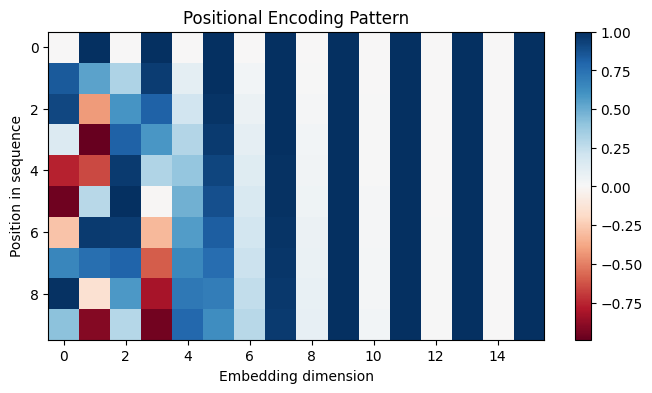

In [ ]:
def get_positional_encoding(seq_len, d_model):
    positions = np.arange(seq_len)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / np.float32(d_model))
    angle_rads = positions * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

pe_sample = get_positional_encoding(seq_len=10, d_model=16)
print("Positional encoding shape:", pe_sample.shape)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.imshow(pe_sample[0].numpy(), cmap='RdBu', aspect='auto')
plt.xlabel('Embedding dimension')
plt.ylabel('Position in sequence')
plt.title('Positional Encoding Pattern')
plt.colorbar()
plt.show()

In [ ]:
from tensorflow.keras import layers, models
class EncoderBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(d_model),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False, mask=None):
        # self-attention: every token attends to every other token (including itself)
        attn_output = self.mha(query=x, key=x, value=x, attention_mask=mask, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.norm1(x + attn_output)  # residual connection + layer norm

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.norm2(out1 + ffn_output)  # residual connection + layer norm

        return out2

# quick standalone test
test_block = EncoderBlock(d_model=64, num_heads=4, ff_dim=128)
dummy_input = tf.random.uniform((2, 25, 64))  # (batch, seq_len, d_model)
output = test_block(dummy_input)
print("Encoder block input shape:", dummy_input.shape)
print("Encoder block output shape:", output.shape)

Encoder block input shape: (2, 25, 64)
Encoder block output shape: (2, 25, 64)


In [ ]:
class DecoderBlock(layers.Layer):
    def __init__(self, d_model, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)  # masked self-attn
        self.mha2 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)  # cross-attn
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(d_model),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)
        self.dropout3 = layers.Dropout(dropout_rate)

    def call(self, x, encoder_output, training=False, causal_mask=None, cross_mask=None):
        # 1. masked self-attention (decoder attends to itself, can't see future tokens)
        attn1 = self.mha1(query=x, key=x, value=x, attention_mask=causal_mask, training=training)
        attn1 = self.dropout1(attn1, training=training)
        out1 = self.norm1(x + attn1)

        # 2. cross-attention (decoder attends to encoder output)
        attn2 = self.mha2(query=out1, key=encoder_output, value=encoder_output, attention_mask=cross_mask, training=training)
        attn2 = self.dropout2(attn2, training=training)
        out2 = self.norm2(out1 + attn2)

        # 3. feed-forward
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output, training=training)
        out3 = self.norm3(out2 + ffn_output)

        return out3

# quick standalone test
test_decoder_block = DecoderBlock(d_model=64, num_heads=4, ff_dim=128)
dummy_decoder_input = tf.random.uniform((2, 23, 64))
dummy_encoder_output = tf.random.uniform((2, 25, 64))  # note: different seq_len than decoder is fine
output = test_decoder_block(dummy_decoder_input, dummy_encoder_output)
print("Decoder block output shape:", output.shape)

Decoder block output shape: (2, 23, 64)


In [ ]:
def create_causal_mask(seq_len):
    # lower triangular matrix: True where attention IS allowed (position j <= position i)
    mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    return tf.cast(mask, tf.bool)

causal_mask_sample = create_causal_mask(6)
print("Causal mask (True = can attend, False = blocked):")
print(causal_mask_sample.numpy())

Causal mask (True = can attend, False = blocked):
[[ True False False False False False]
 [ True  True False False False False]
 [ True  True  True False False False]
 [ True  True  True  True False False]
 [ True  True  True  True  True False]
 [ True  True  True  True  True  True]]


In [ ]:
D_MODEL = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 2
DROPOUT_RATE = 0.1

# --- Encoder ---
encoder_inputs = layers.Input(shape=(MAX_SRC_LEN,), name="encoder_input")
enc_embedding_layer = layers.Embedding(VOCAB_SIZE, D_MODEL, name="encoder_embedding")
enc_embed = enc_embedding_layer(encoder_inputs)
enc_embed = enc_embed + get_positional_encoding(MAX_SRC_LEN, D_MODEL)

# padding mask for encoder self-attention (so real tokens don't attend to <PAD>)
enc_padding_mask = tf.cast(tf.not_equal(encoder_inputs, 0), tf.float32)
enc_padding_mask = enc_padding_mask[:, tf.newaxis, tf.newaxis, :]  # broadcastable shape

x = enc_embed
for i in range(NUM_LAYERS):
    x = EncoderBlock(D_MODEL, NUM_HEADS, FF_DIM, DROPOUT_RATE, name=f"encoder_block_{i}")(x, mask=enc_padding_mask)
encoder_output = x

# --- Decoder ---
decoder_inputs = layers.Input(shape=(DECODER_LEN,), name="decoder_input")
dec_embedding_layer = layers.Embedding(VOCAB_SIZE, D_MODEL, name="decoder_embedding")
dec_embed = dec_embedding_layer(decoder_inputs)
dec_embed = dec_embed + get_positional_encoding(DECODER_LEN, D_MODEL)

causal_mask = create_causal_mask(DECODER_LEN)

y = dec_embed
for i in range(NUM_LAYERS):
    y = DecoderBlock(D_MODEL, NUM_HEADS, FF_DIM, DROPOUT_RATE, name=f"decoder_block_{i}")(
        y, encoder_output, causal_mask=causal_mask, cross_mask=enc_padding_mask
    )

final_dense = layers.Dense(VOCAB_SIZE, name="output_projection")
logits = final_dense(y)
predictions = layers.Activation('softmax')(logits)

transformer_model = models.Model([encoder_inputs, decoder_inputs], predictions)
transformer_model.compile(optimizer='adam', loss=masked_loss, metrics=[masked_accuracy])
transformer_model.summary()

ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [ ]:
D_MODEL = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 2
DROPOUT_RATE = 0.1

# --- Encoder ---
encoder_inputs = layers.Input(shape=(MAX_SRC_LEN,), name="encoder_input")
enc_embedding_layer = layers.Embedding(VOCAB_SIZE, D_MODEL, name="encoder_embedding")
enc_embed = enc_embedding_layer(encoder_inputs)
enc_embed = enc_embed + get_positional_encoding(MAX_SRC_LEN, D_MODEL)

# padding mask for encoder self-attention -- wrapped in Lambda for Keras 3 compatibility
def make_padding_mask(x):
    mask = tf.cast(tf.not_equal(x, 0), tf.float32)
    return mask[:, tf.newaxis, tf.newaxis, :]

enc_padding_mask = layers.Lambda(make_padding_mask, name="enc_padding_mask")(encoder_inputs)

x = enc_embed
for i in range(NUM_LAYERS):
    x = EncoderBlock(D_MODEL, NUM_HEADS, FF_DIM, DROPOUT_RATE, name=f"encoder_block_{i}")(x, mask=enc_padding_mask)
encoder_output = x

# --- Decoder ---
decoder_inputs = layers.Input(shape=(DECODER_LEN,), name="decoder_input")
dec_embedding_layer = layers.Embedding(VOCAB_SIZE, D_MODEL, name="decoder_embedding")
dec_embed = dec_embedding_layer(decoder_inputs)
dec_embed = dec_embed + get_positional_encoding(DECODER_LEN, D_MODEL)

# causal mask is a fixed constant (doesn't depend on input), so build it directly as a constant tensor
causal_mask_const = create_causal_mask(DECODER_LEN)

y = dec_embed
for i in range(NUM_LAYERS):
    y = DecoderBlock(D_MODEL, NUM_HEADS, FF_DIM, DROPOUT_RATE, name=f"decoder_block_{i}")(
        y, encoder_output, causal_mask=causal_mask_const, cross_mask=enc_padding_mask
    )

final_dense = layers.Dense(VOCAB_SIZE, name="output_projection")
logits = final_dense(y)
predictions = layers.Activation('softmax')(logits)

transformer_model = models.Model([encoder_inputs, decoder_inputs], predictions)
transformer_model.compile(optimizer='adam', loss=masked_loss, metrics=[masked_accuracy])
transformer_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_block_0' (of type EncoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_block_1' (of type EncoderBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 25, 64)    │    187,136 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 23)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 25, 64)    │          0 │ encoder_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_padding_mask    │ (None, 1, 1, 25)  │          0 │ encoder_input[0]… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 23, 64)    │    187,136 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_0     │ (None, 25, 64)    │     33,472 │ add_1[0][0],      │
│ (EncoderBlock)      │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 23, 64)    │          0 │ decoder_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_block_1     │ (None, 25, 64)    │     33,472 │ encoder_block_0[… │
│ (EncoderBlock)      │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block_0     │ (None, 23, 64)    │     50,240 │ add_2[0][0],      │
│ (DecoderBlock)      │                   │            │ encoder_block_1[… │
│                     │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_block_1     │ (None, 23, 64)    │     50,240 │ decoder_block_0[… │
│ (DecoderBlock)      │                   │            │ encoder_block_1[… │
│                     │                   │            │ enc_padding_mask… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_projection   │ (None, 23, 2924)  │    190,060 │ decoder_block_1[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 23, 2924)  │          0 │ output_projectio… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 731,756 (2.79 MB)

 Trainable params: 731,756 (2.79 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop_transformer = EarlyStopping(
    monitor='val_masked_accuracy',
    mode='max',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_transformer = transformer_model.fit(
    [X_train, decoder_input_train], decoder_target_train,
    validation_data=([X_dev, decoder_input_dev], decoder_target_dev),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop_transformer],
    verbose=1
)

print("\nBest val_masked_accuracy:", max(history_transformer.history['val_masked_accuracy']))

Epoch 1/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 46s 380ms/step - loss: 6.7117 - masked_accuracy: 0.1746 - val_loss: 5.7111 - val_masked_accuracy: 0.2535
Epoch 2/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.2797 - masked_accuracy: 0.2553 - val_loss: 5.1314 - val_masked_accuracy: 0.2730
Epoch 3/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 4.7992 - masked_accuracy: 0.2848 - val_loss: 4.8609 - val_masked_accuracy: 0.2948
Epoch 4/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.4378 - masked_accuracy: 0.3174 - val_loss: 4.5913 - val_masked_accuracy: 0.3370
Epoch 5/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.0631 - masked_accuracy: 0.3585 - val_loss: 4.3674 - val_masked_accuracy: 0.3627
Epoch 6/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3.7172 - masked_accuracy: 0.4043 - val_loss: 4.1494 - val_masked_accuracy: 0.3972
Epoch 7/60
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.4036 - masked_accuracy: 0.4414 - val_loss: 3.9838 - val_masked_accuracy: 0.4118
Epoch 8/60
5

In [ ]:
import re

def tokenize(text):
    text = text.strip().lower()
    tokens = re.findall(r"[a-z]+(?:'[a-z]+)?|[.,!?;:()\"]", text)
    return tokens

def encode(tokens, stoi):
    return [stoi.get(t, stoi[UNK]) for t in tokens]
def correct_sentence_transformer(input_text, max_len=DECODER_LEN):
    src_tokens = encode(tokenize(input_text), stoi)
    src_padded = pad_sequences([src_tokens], maxlen=MAX_SRC_LEN, padding='post', value=stoi[PAD])

    output_tokens = []
    decoder_infer_input = np.zeros((1, max_len))
    decoder_infer_input[0, 0] = stoi[START]

    for t in range(max_len - 1):
        padded_input = np.zeros((1, max_len))
        padded_input[0, :t+1] = decoder_infer_input[0, :t+1]

        preds = transformer_model.predict([src_padded, padded_input], verbose=0)
        next_token_id = np.argmax(preds[0, t])

        if itos[next_token_id] == END:
            break
        output_tokens.append(itos[next_token_id])
        if t + 1 < max_len:
            decoder_infer_input[0, t+1] = next_token_id

    return ' '.join(output_tokens)

test_sentences = [
    "She go to school every day.",
    "John and me went to the store yesterday.",
    "He no likes pineapple on his pizza.",
    "The books is on the shelf.",
]

for s in test_sentences:
    corrected = correct_sentence_transformer(s)
    print(f"IN:  {s}")
    print(f"OUT: {corrected}")
    print()

IN:  She go to school every day.
OUT: she goes to school every day .

IN:  John and me went to the store yesterday.
OUT: john and i went to the store yesterday .

IN:  He no likes pineapple on his pizza.
OUT: he doesn't like pineapple on his pizza .

IN:  The books is on the shelf.
OUT: the books is on the shelf .



In [ ]:
!pip install -q sacrebleu

import sacrebleu

# Decode all 202 test examples
test_sources = df.iloc[test_idx]['Ungrammatical Statement'].tolist() if 'test_idx' in dir() else None

# reconstruct test sentences from X_test (safer, since test_idx may not be in this session)
def decode_ids(id_seq, itos):
    tokens = []
    for i in id_seq:
        tok = itos[i]
        if tok == PAD:
            break
        if tok not in (START, END):
            tokens.append(tok)
    return ' '.join(tokens)

test_sources_decoded = [decode_ids(seq, itos) for seq in X_test]
test_targets_decoded = [decode_ids(seq, itos) for seq in Y_test]

predictions = []
for i, src_ids in enumerate(X_test):
    src_padded = src_ids.reshape(1, -1)

    output_tokens = []
    decoder_infer_input = np.zeros((1, DECODER_LEN))
    decoder_infer_input[0, 0] = stoi[START]

    for t in range(DECODER_LEN - 1):
        padded_input = np.zeros((1, DECODER_LEN))
        padded_input[0, :t+1] = decoder_infer_input[0, :t+1]
        preds = transformer_model.predict([src_padded, padded_input], verbose=0)
        next_token_id = np.argmax(preds[0, t])
        if itos[next_token_id] == END:
            break
        output_tokens.append(itos[next_token_id])
        if t + 1 < DECODER_LEN:
            decoder_infer_input[0, t+1] = next_token_id

    predictions.append(' '.join(output_tokens))

    if (i + 1) % 50 == 0:
        print(f"Decoded {i+1}/{len(X_test)}...")

# Exact match accuracy
exact_matches = sum(1 for p, t in zip(predictions, test_targets_decoded) if p.strip() == t.strip())
exact_match_acc = exact_matches / len(predictions)
print(f"\nExact match accuracy: {exact_match_acc:.3f} ({exact_matches}/{len(predictions)})")

# BLEU score (corpus-level)
bleu = sacrebleu.corpus_bleu(predictions, [test_targets_decoded])
print(f"BLEU score: {bleu.score:.2f}")

# show a few examples for sanity check
print("\nSample predictions:")
for i in range(5):
    print(f"SRC:  {test_sources_decoded[i]}")
    print(f"TGT:  {test_targets_decoded[i]}")
    print(f"PRED: {predictions[i]}")
    print()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 7.3 MB/s eta 0:00:00
Decoded 50/202...
Decoded 100/202...
Decoded 150/202...
Decoded 200/202...



Exact match accuracy: 0.050 (10/202)
BLEU score: 35.12

Sample predictions:
SRC:  the <UNK> study focused on <UNK> and <UNK> <UNK> .
TGT:  the scientific study focused on <UNK> acid and <UNK> acid <UNK> .
PRED: the <UNK> study focused on <UNK> and <UNK> <UNK> <UNK> .

SRC:  the chef's signature dish is made by <UNK> vegetables and herbs .
TGT:  the chef's signature dish is made by <UNK> vegetables and herbs .
PRED: the assistant printed me is made by oil vegetables .

SRC:  the manager expects her team to be punctual , respectful , and that they should be motivated .
TGT:  the manager expects her team to be punctual , respectful , and motivated .
PRED: the manager expects , " to be punctual , reduce waste , and their performance .

SRC:  i want to travel , or i want to save money .
TGT:  i want to either travel or save money .
PRED: i want to travel and or her want to go shopping .

SRC:  the team worked hard . . . completed the project on time .
TGT:  the team worked hard and complet

In [ ]:
def beam_search_transformer(input_text, beam_width=5, max_len=DECODER_LEN):
    src_tokens = encode(tokenize(input_text), stoi)
    src_padded = pad_sequences([src_tokens], maxlen=MAX_SRC_LEN, padding='post', value=stoi[PAD])

    # each beam: (token_id_sequence, cumulative_log_prob)
    start_seq = [stoi[START]]
    beams = [(start_seq, 0.0)]

    for t in range(max_len - 1):
        all_candidates = []

        for seq, score in beams:
            # if this beam already ended, keep it as-is (don't extend further)
            if seq[-1] == stoi[END]:
                all_candidates.append((seq, score))
                continue

            padded_input = np.zeros((1, max_len))
            padded_input[0, :len(seq)] = seq
            preds = transformer_model.predict([src_padded, padded_input], verbose=0)
            next_token_probs = preds[0, len(seq) - 1]  # distribution for the next token

            # get top beam_width candidates for this beam
            top_k_ids = np.argsort(next_token_probs)[-beam_width:]
            for token_id in top_k_ids:
                prob = next_token_probs[token_id]
                new_score = score + np.log(prob + 1e-10)
                all_candidates.append((seq + [int(token_id)], new_score))

        # keep only the best beam_width sequences overall (normalize by length to avoid short-sequence bias)
        all_candidates.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
        beams = all_candidates[:beam_width]

        # stop early if all beams have ended
        if all(seq[-1] == stoi[END] for seq, _ in beams):
            break

    best_seq, best_score = beams[0]
    tokens = [itos[i] for i in best_seq[1:] if itos[i] not in (END, PAD)]
    return ' '.join(tokens)

# test on the same 4 sentences
test_sentences = [
    "She go to school every day.",
    "John and me went to the store yesterday.",
    "He no likes pineapple on his pizza.",
    "The books is on the shelf.",
]

for s in test_sentences:
    corrected = beam_search_transformer(s)
    print(f"IN:  {s}")
    print(f"OUT: {corrected}")
    print()

IN:  She go to school every day.
OUT: she goes to school every day .

IN:  John and me went to the store yesterday.
OUT: john and i went to the store yesterday .

IN:  He no likes pineapple on his pizza.
OUT: he doesn't like pineapple on his pizza .

IN:  The books is on the shelf.
OUT: the books is on the shelf .



In [ ]:
harder_sentences = [
    "the manager expects her team to be punctual , respectful , and that they should be motivated .",
    "i want to travel , or i want to save money .",
    "the team worked hard . . . completed the project on time .",
]

for s in harder_sentences:
    corrected = beam_search_transformer(s)
    print(f"IN:  {s}")
    print(f"OUT: {corrected}")
    print()

IN:  the manager expects her team to be punctual , respectful , and that they should be motivated .
OUT: the manager expects movie to be punctual , professional , and helpful movie .

IN:  i want to travel , or i want to save money .
OUT: i want to travel , or i want to go shopping .

IN:  the team worked hard . . . completed the project on time .
OUT: the team worked hard , but i heard the project .



In [ ]:
transformer_model.save('/content/drive/MyDrive/gec_project/phase6_transformer_model.keras')
print("Model saved to /content/phase6_embedding_model.keras")

Model saved to /content/phase6_embedding_model.keras


In [ ]:
import os

SAVE_DIR = '/content/drive/MyDrive/gec_project'

# rename to match actual phase content
os.rename('/content/phase5_gru_model.keras', f'{SAVE_DIR}/phase4b_attention_model.keras')
os.rename(f'{SAVE_DIR}/phase6_transformer_model.keras', f'{SAVE_DIR}/phase5_transformer_model.keras')

print("Renamed. Current files in Drive:")
for f in os.listdir(SAVE_DIR):
    print(" -", f)

OSError: [Errno 18] Invalid cross-device link: '/content/phase5_gru_model.keras' -> '/content/drive/MyDrive/gec_project/phase4b_attention_model.keras'

In [ ]:
import shutil
import os

SAVE_DIR = '/content/drive/MyDrive/gec_project'

# copy across filesystems, then remove original
shutil.copy('/content/phase5_gru_model.keras', f'{SAVE_DIR}/phase4b_attention_model.keras')
os.remove('/content/phase5_gru_model.keras')

# this one's already within Drive, so plain rename works fine
os.rename(f'{SAVE_DIR}/phase6_transformer_model.keras', f'{SAVE_DIR}/phase5_transformer_model.keras')

print("Done. Current files in Drive:")
for f in os.listdir(SAVE_DIR):
    print(" -", f)

FileNotFoundError: [Errno 2] No such file or directory: '/content/phase5_gru_model.keras'

In [ ]:
import os

print("Files in /content/:")
for f in os.listdir('/content'):
    if f.endswith('.keras'):
        print(" -", f)

print("\nFiles in Drive project folder:")
for f in os.listdir('/content/drive/MyDrive/gec_project'):
    print(" -", f)

Files in /content/:

Files in Drive project folder:
 - phase2_rnn_model.keras
 - phase3_lstm_model.keras
 - phase4_gru_model.keras
 - phase4b_attention_model.keras
 - vocab_and_data.pkl
 - phase6_transformer_model.keras


In [ ]:
import os

SAVE_DIR = '/content/drive/MyDrive/gec_project'

os.rename(f'{SAVE_DIR}/phase6_transformer_model.keras', f'{SAVE_DIR}/phase5_transformer_model.keras')

print("Fixed. Current files in Drive:")
for f in sorted(os.listdir(SAVE_DIR)):
    print(" -", f)

Fixed. Current files in Drive:
 - phase2_rnn_model.keras
 - phase3_lstm_model.keras
 - phase4_gru_model.keras
 - phase4b_attention_model.keras
 - phase5_transformer_model.keras
 - vocab_and_data.pkl


In [ ]:
!pip install -q transformers sentencepiece

import tensorflow as tf
from transformers import T5Tokenizer, TFT5ForConditionalGeneration

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

ImportError: cannot import name 'TFT5ForConditionalGeneration' from 'transformers' (/usr/local/lib/python3.13/dist-packages/transformers/__init__.py)

In [ ]:
import transformers
print("Transformers version:", transformers.__version__)

# check what T5-related classes actually exist
available = [x for x in dir(transformers) if 'T5' in x]
print("\nAvailable T5 classes:", available)

Transformers version: 5.15.0

Available T5 classes: ['ByT5Tokenizer', 'LongT5Config', 'LongT5EncoderModel', 'LongT5ForConditionalGeneration', 'LongT5Model', 'LongT5PreTrainedModel', 'MT5Config', 'MT5EncoderModel', 'MT5ForConditionalGeneration', 'MT5ForQuestionAnswering', 'MT5ForSequenceClassification', 'MT5ForTokenClassification', 'MT5Model', 'MT5PreTrainedModel', 'MyT5Tokenizer', 'SpeechT5Config', 'SpeechT5FeatureExtractor', 'SpeechT5ForSpeechToSpeech', 'SpeechT5ForSpeechToText', 'SpeechT5ForTextToSpeech', 'SpeechT5HifiGan', 'SpeechT5HifiGanConfig', 'SpeechT5Model', 'SpeechT5PreTrainedModel', 'SpeechT5Processor', 'SpeechT5Tokenizer', 'T5Config', 'T5EncoderModel', 'T5ForConditionalGeneration', 'T5ForQuestionAnswering', 'T5ForSequenceClassification', 'T5ForTokenClassification', 'T5Gemma2Config', 'T5Gemma2DecoderConfig', 'T5Gemma2Encoder', 'T5Gemma2EncoderConfig', 'T5Gemma2ForConditionalGeneration', 'T5Gemma2ForSequenceClassification', 'T5Gemma2ForTokenClassification', 'T5Gemma2Model', '

In [ ]:
import torch
from transformers import T5Tokenizer, T5ForConditionalGeneration

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Torch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [ ]:
model_name = "t5-small"

tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)

print("Model loaded:", model_name)
print("Number of parameters:", sum(p.numel() for p in model.parameters()))

# quick sanity check: try it completely untrained on our task (zero-shot)
test_input = "grammar: She go to school every day."
input_ids = tokenizer(test_input, return_tensors="pt").input_ids.to(device)
output_ids = model.generate(input_ids, max_length=30)
output_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print(f"\nZero-shot test (before any fine-tuning):")
print(f"IN:  {test_input}")
print(f"OUT: {output_text}")

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  242MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded: t5-small
Number of parameters: 60506624

Zero-shot test (before any fine-tuning):
IN:  grammar: She go to school every day.
OUT: Sie hat grammatisch: Sie schult täglich.


In [ ]:
import pandas as pd

df = pd.read_csv('/content/Grammar Correction.csv')
print(df.shape)
df.head()

(2018, 4)


,Serial Number,Error Type,Ungrammatical Statement,Standard English
0,1,Verb Tense Errors,I goes to the store everyday.,I go to the store everyday.
1,2,Verb Tense Errors,They was playing soccer last night.,They were playing soccer last night.
2,3,Verb Tense Errors,She have completed her homework.,She has completed her homework.
3,4,Verb Tense Errors,He don't know the answer.,He doesn't know the answer.
4,5,Verb Tense Errors,The sun rise in the east.,The sun rises in the east.


In [ ]:
from sklearn.model_selection import train_test_split

# reuse the original dataframe's raw text (not our custom-tokenized IDs)
sources = df['Ungrammatical Statement'].tolist()
targets = df['Standard English'].tolist()

# prefix every source with our task instruction
prefixed_sources = [f"grammar: {s}" for s in sources]

# same stratified split logic as before, by error type
error_types = df['Error Type'].values
indices = list(range(len(df)))

train_idx_t5, temp_idx_t5 = train_test_split(indices, test_size=0.2, random_state=42, stratify=error_types)
dev_idx_t5, test_idx_t5 = train_test_split(temp_idx_t5, test_size=0.5, random_state=42, stratify=error_types[temp_idx_t5])

train_sources = [prefixed_sources[i] for i in train_idx_t5]
train_targets = [targets[i] for i in train_idx_t5]
dev_sources = [prefixed_sources[i] for i in dev_idx_t5]
dev_targets = [targets[i] for i in dev_idx_t5]
test_sources_t5 = [prefixed_sources[i] for i in test_idx_t5]
test_targets_t5 = [targets[i] for i in test_idx_t5]

print(f"Train: {len(train_sources)}  Dev: {len(dev_sources)}  Test: {len(test_sources_t5)}")
print("\nSample:")
print("SRC:", train_sources[0])
print("TGT:", train_targets[0])

# check token lengths using T5's own tokenizer
sample_lens = [len(tokenizer(s).input_ids) for s in train_sources[:100]]
print("\nSample tokenized lengths (T5 subword tokenizer):", min(sample_lens), "-", max(sample_lens))

Train: 1614  Dev: 202  Test: 202

Sample:
SRC: grammar: The song was performed by the choir at the concert.
TGT: The choir performed the song at the concert.

Sample tokenized lengths (T5 subword tokenizer): 10 - 22


In [ ]:
MAX_INPUT_LEN = 32
MAX_TARGET_LEN = 32

def tokenize_batch(sources, targets):
    model_inputs = tokenizer(
        sources, max_length=MAX_INPUT_LEN, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    labels = tokenizer(
        targets, max_length=MAX_TARGET_LEN, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    # T5 convention: replace pad token id in labels with -100 so it's ignored in loss
    label_ids = labels.input_ids.clone()
    label_ids[label_ids == tokenizer.pad_token_id] = -100

    return model_inputs.input_ids, model_inputs.attention_mask, label_ids

train_input_ids, train_attention_mask, train_labels = tokenize_batch(train_sources, train_targets)
dev_input_ids, dev_attention_mask, dev_labels = tokenize_batch(dev_sources, dev_targets)

print("Train input_ids shape:", train_input_ids.shape)
print("Train labels shape:", train_labels.shape)
print("\nSample input_ids[0]:", train_input_ids[0][:15])
print("Sample labels[0]:", train_labels[0][:15])

Train input_ids shape: torch.Size([1614, 32])
Train labels shape: torch.Size([1614, 32])

Sample input_ids[0]: tensor([19519,    10,    37,  2324,    47,  3032,    57,     8, 20778,    44,
            8,  4219,     5,     1,     0])
Sample labels[0]: tensor([   37, 20778,  3032,     8,  2324,    44,     8,  4219,     5,     1,
         -100,  -100,  -100,  -100,  -100])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW

BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 3e-4

train_dataset = TensorDataset(train_input_ids, train_attention_mask, train_labels)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

dev_dataset = TensorDataset(dev_input_ids, dev_attention_mask, dev_labels)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

def evaluate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for input_ids, attention_mask, labels in loader:
            input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
    return total_loss / len(loader)

best_val_loss = float('inf')
patience = 3
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    for input_ids, attention_mask, labels in train_loader:
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = evaluate(model, dev_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {avg_train_loss:.4f} - val_loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), '/content/best_t5_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest val_loss: {best_val_loss:.4f}")
# reload best weights
model.load_state_dict(torch.load('/content/best_t5_model.pt'))

Epoch 1/10 - train_loss: 0.4924 - val_loss: 0.3285
Epoch 2/10 - train_loss: 0.2785 - val_loss: 0.2978
Epoch 3/10 - train_loss: 0.2101 - val_loss: 0.3007
Epoch 4/10 - train_loss: 0.1557 - val_loss: 0.2971
Epoch 5/10 - train_loss: 0.1177 - val_loss: 0.3033
Epoch 6/10 - train_loss: 0.0937 - val_loss: 0.3034
Epoch 7/10 - train_loss: 0.0727 - val_loss: 0.3134
Early stopping at epoch 7

Best val_loss: 0.2971


<All keys matched successfully>

In [ ]:
def correct_sentence_t5(text, max_length=32):
    model.eval()
    input_text = f"grammar: {text}"
    input_ids = tokenizer(input_text, return_tensors='pt', truncation=True, max_length=MAX_INPUT_LEN).input_ids.to(device)
    with torch.no_grad():
        output_ids = model.generate(input_ids, max_length=max_length, num_beams=5, early_stopping=True)
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

standard_sentences = [
    "She go to school every day.",
    "John and me went to the store yesterday.",
    "He no likes pineapple on his pizza.",
    "The books is on the shelf.",
]

hard_sentences = [
    "the manager expects her team to be punctual , respectful , and that they should be motivated .",
    "i want to travel , or i want to save money .",
    "the team worked hard . . . completed the project on time .",
]

print("=== Standard sentences ===")
for s in standard_sentences:
    print(f"IN:  {s}")
    print(f"OUT: {correct_sentence_t5(s)}")
    print()

print("=== Hard sentences (broke every from-scratch model) ===")
for s in hard_sentences:
    print(f"IN:  {s}")
    print(f"OUT: {correct_sentence_t5(s)}")
    print()

=== Standard sentences ===
IN:  She go to school every day.
OUT: She goes to school every day.

IN:  John and me went to the store yesterday.
OUT: John and I went to the store yesterday.

IN:  He no likes pineapple on his pizza.
OUT: He doesn't like pineapple on his pizza.

IN:  The books is on the shelf.
OUT: The books are on the shelf.

=== Hard sentences (broke every from-scratch model) ===
IN:  the manager expects her team to be punctual , respectful , and that they should be motivated .
OUT: The manager expects her team to be punctual, respectful, and motivate.

IN:  i want to travel , or i want to save money .
OUT: I want to travel or save money.

IN:  the team worked hard . . . completed the project on time .
OUT: The team worked hard to complete the project on time.



In [ ]:
import sacrebleu

predictions_t5 = []
for i, src in enumerate(test_sources_t5):
    # src already has "grammar: " prefix from earlier prep
    input_ids = tokenizer(src, return_tensors='pt', truncation=True, max_length=MAX_INPUT_LEN).input_ids.to(device)
    with torch.no_grad():
        output_ids = model.generate(input_ids, max_length=32, num_beams=5, early_stopping=True)
    pred = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    predictions_t5.append(pred)

    if (i + 1) % 50 == 0:
        print(f"Decoded {i+1}/{len(test_sources_t5)}...")

# exact match (case-insensitive, since T5 preserves original casing which our targets may differ on slightly)
exact_matches_t5 = sum(
    1 for p, t in zip(predictions_t5, test_targets_t5)
    if p.strip().lower().rstrip('.') == t.strip().lower().rstrip('.')
)
exact_match_acc_t5 = exact_matches_t5 / len(predictions_t5)
print(f"\nExact match accuracy (case-insensitive): {exact_match_acc_t5:.3f} ({exact_matches_t5}/{len(predictions_t5)})")

bleu_t5 = sacrebleu.corpus_bleu(predictions_t5, [test_targets_t5])
print(f"BLEU score: {bleu_t5.score:.2f}")

# show a few random samples for sanity check
import random
random.seed(1)
sample_indices = random.sample(range(len(predictions_t5)), 5)
print("\nSample predictions:")
for i in sample_indices:
    print(f"SRC:  {test_sources_t5[i].replace('grammar: ', '')}")
    print(f"TGT:  {test_targets_t5[i]}")
    print(f"PRED: {predictions_t5[i]}")
    print()

Decoded 50/202...
Decoded 100/202...
Decoded 150/202...
Decoded 200/202...

Exact match accuracy (case-insensitive): 0.579 (117/202)
BLEU score: 84.08

Sample predictions:
SRC:  Please RSVP in advance, ahead of time.
TGT:  Please RSVP in advance.
PRED: Please RSVP in advance.

SRC:  The most shortest route is through the park.
TGT:  The shortest route is through the park.
PRED: The shortest route is through the park.

SRC:  The books is on the desk.
TGT:  The books are on the desk.
PRED: The books are on the desk.

SRC:  She didn't give no explanation.
TGT:  She didn't give any explanation.
PRED: She didn't give any explanation.

SRC:  The weather today is most hotter than yesterday.
TGT:  The weather today is hotter than yesterday.
PRED: The weather today is hotter than yesterday.



In [ ]:
import torch.nn.functional as F

def compute_token_accuracy(model, input_ids, attention_mask, labels, batch_size=16):
    model.eval()
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for i in range(0, len(input_ids), batch_size):
            batch_input = input_ids[i:i+batch_size].to(device)
            batch_mask = attention_mask[i:i+batch_size].to(device)
            batch_labels = labels[i:i+batch_size].to(device)

            outputs = model(input_ids=batch_input, attention_mask=batch_mask, labels=batch_labels)
            logits = outputs.logits  # (batch, seq_len, vocab_size)
            preds = torch.argmax(logits, dim=-1)

            # mask out -100 (padding) positions
            mask = (batch_labels != -100)
            correct = (preds == batch_labels) & mask

            total_correct += correct.sum().item()
            total_count += mask.sum().item()

    return total_correct / total_count

# tokenize the test set the same way we did train/dev
test_input_ids, test_attention_mask, test_labels = tokenize_batch(test_sources_t5, test_targets_t5)

t5_token_accuracy = compute_token_accuracy(model, test_input_ids, test_attention_mask, test_labels)
print(f"T5 token-level (teacher-forced) accuracy on test set: {t5_token_accuracy:.4f}")

T5 token-level (teacher-forced) accuracy on test set: 0.9480


In [ ]:
model_name_base = "t5-base"

tokenizer_base = T5Tokenizer.from_pretrained(model_name_base)
model_base = T5ForConditionalGeneration.from_pretrained(model_name_base).to(device)

print("Model loaded:", model_name_base)
print("Number of parameters:", sum(p.numel() for p in model_base.parameters()))

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  892MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Model loaded: t5-base
Number of parameters: 222903552


In [ ]:
model.save_pretrained('/content/drive/MyDrive/gec_project/phase6_t5_finetuned')
tokenizer.save_pretrained('/content/drive/MyDrive/gec_project/phase6_t5_finetuned')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/gec_project/phase6_t5_finetuned/tokenizer_config.json',
 '/content/drive/MyDrive/gec_project/phase6_t5_finetuned/tokenizer.json')

In [ ]:
def tokenize_batch_base(sources, targets, tok):
    model_inputs = tok(
        sources, max_length=MAX_INPUT_LEN, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    labels = tok(
        targets, max_length=MAX_TARGET_LEN, padding='max_length',
        truncation=True, return_tensors='pt'
    )
    label_ids = labels.input_ids.clone()
    label_ids[label_ids == tok.pad_token_id] = -100
    return model_inputs.input_ids, model_inputs.attention_mask, label_ids

train_input_ids_b, train_attention_mask_b, train_labels_b = tokenize_batch_base(train_sources, train_targets, tokenizer_base)
dev_input_ids_b, dev_attention_mask_b, dev_labels_b = tokenize_batch_base(dev_sources, dev_targets, tokenizer_base)

BATCH_SIZE_BASE = 8  # smaller batch for the bigger model
EPOCHS_BASE = 10
LEARNING_RATE_BASE = 3e-4

train_dataset_b = TensorDataset(train_input_ids_b, train_attention_mask_b, train_labels_b)
train_loader_b = DataLoader(train_dataset_b, batch_size=BATCH_SIZE_BASE, shuffle=True)

dev_dataset_b = TensorDataset(dev_input_ids_b, dev_attention_mask_b, dev_labels_b)
dev_loader_b = DataLoader(dev_dataset_b, batch_size=BATCH_SIZE_BASE, shuffle=False)

optimizer_b = AdamW(model_base.parameters(), lr=LEARNING_RATE_BASE)

best_val_loss_b = float('inf')
patience_b = 3
patience_counter_b = 0

for epoch in range(EPOCHS_BASE):
    model_base.train()
    total_train_loss = 0

    for input_ids, attention_mask, labels in train_loader_b:
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        optimizer_b.zero_grad()
        outputs = model_base(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer_b.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader_b)
    avg_val_loss = evaluate(model_base, dev_loader_b)

    print(f"Epoch {epoch+1}/{EPOCHS_BASE} - train_loss: {avg_train_loss:.4f} - val_loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss_b:
        best_val_loss_b = avg_val_loss
        patience_counter_b = 0
        torch.save(model_base.state_dict(), '/content/best_t5_base_model.pt')
    else:
        patience_counter_b += 1
        if patience_counter_b >= patience_b:
            print(f"Early stopping at epoch {epoch+1}")
            break

print(f"\nBest val_loss: {best_val_loss_b:.4f}")
model_base.load_state_dict(torch.load('/content/best_t5_base_model.pt'))

Epoch 1/10 - train_loss: 0.2777 - val_loss: 0.1907
Epoch 2/10 - train_loss: 0.1039 - val_loss: 0.2022
Epoch 3/10 - train_loss: 0.0611 - val_loss: 0.2201
Epoch 4/10 - train_loss: 0.0302 - val_loss: 0.2549
Early stopping at epoch 4

Best val_loss: 0.1907


<All keys matched successfully>

In [ ]:
predictions_t5_base = []
for i, src in enumerate(test_sources_t5):
    input_ids = tokenizer_base(src, return_tensors='pt', truncation=True, max_length=MAX_INPUT_LEN).input_ids.to(device)
    with torch.no_grad():
        output_ids = model_base.generate(input_ids, max_length=32, num_beams=5, early_stopping=True)
    pred = tokenizer_base.decode(output_ids[0], skip_special_tokens=True)
    predictions_t5_base.append(pred)

    if (i + 1) % 50 == 0:
        print(f"Decoded {i+1}/{len(test_sources_t5)}...")

exact_matches_base = sum(
    1 for p, t in zip(predictions_t5_base, test_targets_t5)
    if p.strip().lower().rstrip('.') == t.strip().lower().rstrip('.')
)
exact_match_acc_base = exact_matches_base / len(predictions_t5_base)
print(f"\nExact match accuracy (t5-base): {exact_match_acc_base:.3f} ({exact_matches_base}/{len(predictions_t5_base)})")

bleu_base = sacrebleu.corpus_bleu(predictions_t5_base, [test_targets_t5])
print(f"BLEU score (t5-base): {bleu_base.score:.2f}")

# token-level accuracy for full consistency with our comparison table
test_input_ids_b, test_attention_mask_b, test_labels_b = tokenize_batch_base(test_sources_t5, test_targets_t5, tokenizer_base)
t5_base_token_accuracy = compute_token_accuracy(model_base, test_input_ids_b, test_attention_mask_b, test_labels_b)
print(f"Token-level accuracy (t5-base): {t5_base_token_accuracy:.4f}")

# test on the hard sentences that gave t5-small trouble
print("\n=== Hard sentence check ===")
hard_sentences_prefixed = [f"grammar: {s}" for s in hard_sentences]
for s in hard_sentences_prefixed:
    input_ids = tokenizer_base(s, return_tensors='pt', truncation=True, max_length=MAX_INPUT_LEN).input_ids.to(device)
    with torch.no_grad():
        output_ids = model_base.generate(input_ids, max_length=32, num_beams=5, early_stopping=True)
    print(f"IN:  {s.replace('grammar: ', '')}")
    print(f"OUT: {tokenizer_base.decode(output_ids[0], skip_special_tokens=True)}")
    print()

Decoded 50/202...
Decoded 100/202...
Decoded 150/202...
Decoded 200/202...

Exact match accuracy (t5-base): 0.599 (121/202)
BLEU score (t5-base): 86.16
Token-level accuracy (t5-base): 0.9598

=== Hard sentence check ===
IN:  the manager expects her team to be punctual , respectful , and that they should be motivated .
OUT: The manager expects her team to be punctual, respectful, and motivated.

IN:  i want to travel , or i want to save money .
OUT: I want to travel or save money.

IN:  the team worked hard . . . completed the project on time .
OUT: The team worked hard and completed the project on time.



In [ ]:
model_base.save_pretrained('/content/drive/MyDrive/gec_project/phase6b_t5base_finetuned')
tokenizer_base.save_pretrained('/content/drive/MyDrive/gec_project/phase6b_t5base_finetuned')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/gec_project/phase6b_t5base_finetuned/tokenizer_config.json',
 '/content/drive/MyDrive/gec_project/phase6b_t5base_finetuned/tokenizer.json')

In [ ]:
model_base = T5ForConditionalGeneration.from_pretrained('/content/drive/MyDrive/gec_project/phase6b_t5base_finetuned')
tokenizer_base = T5Tokenizer.from_pretrained('/content/drive/MyDrive/gec_project/phase6b_t5base_finetuned')

Loading weights:   0%|          | 0/257 [00:00<?, ?it/s]